<a href="https://colab.research.google.com/github/ShaheenPafiast/shaheenfirstCode/blob/main/DIP_Lab_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Name ......................Abdullah Shaheen**

# **Class .....................AI-Blue(2022-2026)**

# **Reg No. ...................B22AIF1045AI114**

# **Submitted To...............Sir Rizwan Shah**

# **Lab report ................  12**

In [6]:
import cv2                  # OpenCV for image processing
import numpy as np         # NumPy for numerical operations
import matplotlib.pyplot as plt  # Matplotlib for visualization
from sklearn.cluster import KMeans  # K-Means clustering from scikit-learn
from skimage.filters import threshold_li  # Li's thresholding from scikit-image

from skimage import io      # For reading/writing images in scikit-image


# **1. Otsu's Thresholding**

Otsu's thresholding is an adaptive, non-parametric method used for automatic threshold selection in image segmentation. It works by iteratively calculating the optimal threshold that maximizes the inter-class variance (variance between foreground and background pixels) while minimizing the intra-class variance (variance within each class). This method assumes that the image histogram is bimodal, meaning it has two distinct peaks representing the foreground and background. Otsu's method is widely used due to its simplicity and effectiveness in separating objects from the background in grayscale images

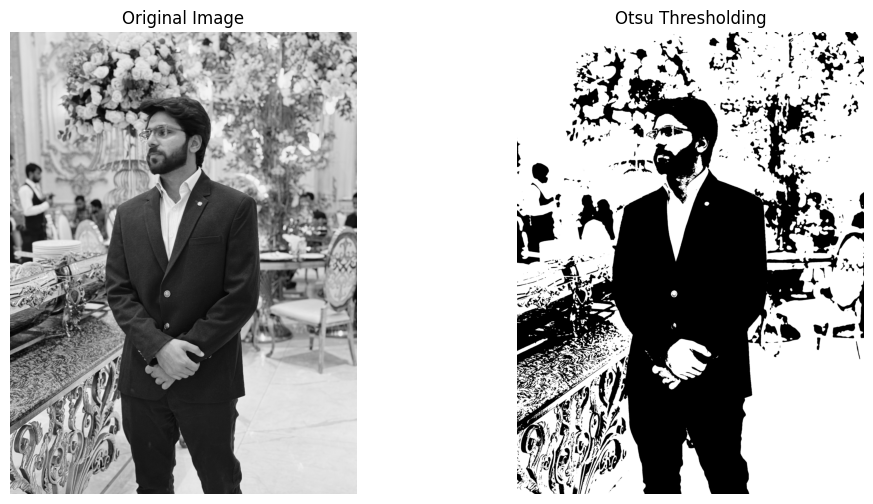

In [17]:
import cv2
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('/content/shaheen.jpg', cv2.IMREAD_GRAYSCALE)

# Apply Otsu's thresholding
_, otsu_thresholded = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(otsu_thresholded, cmap='gray')
plt.title('Otsu Thresholding')
plt.axis('off')

plt.show()


#**2. K-Means Clustering for Thresholding**


K-Means clustering is an unsupervised machine learning algorithm used for partitioning data into distinct clusters based on their features. In image segmentation, K-Means treats each pixel as a data point and groups them into clusters based on their intensity or color values. By setting the number of clusters to 2, the algorithm effectively segments the image into foreground and background. This method is particularly useful for images with complex intensity distributions where a single global threshold may not suffice.



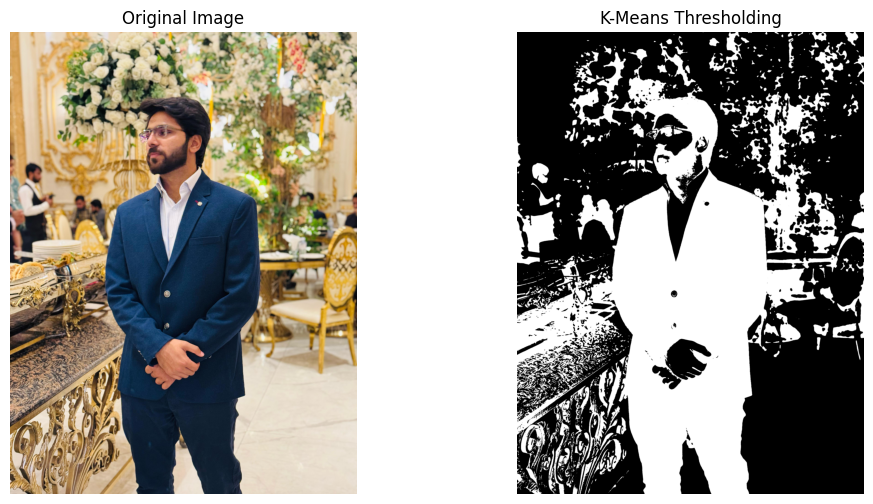

In [16]:
from sklearn.cluster import KMeans
import numpy as np

# Load the image
image = cv2.imread('/content/shaheen.jpg')
image_flat = image.reshape(-1, 3)  # Flatten the image for K-Means

# Apply K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(image_flat)
segmented_image = kmeans.labels_.reshape(image.shape[:2])

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image, cmap='gray')
plt.title('K-Means Thresholding')
plt.axis('off')

plt.show()


#**3. Entropy-Based Thresholding (Li's Method)**


Entropy-based thresholding, such as Li's method, uses information theory to determine the optimal threshold for image segmentation. It aims to minimize the cross-entropy between the original and segmented images, ensuring that the segmented image retains as much information as possible from the original. This method is robust to noise and works well for images with uneven illumination or complex textures. It is particularly effective for images where the histogram does not have distinct peaks.

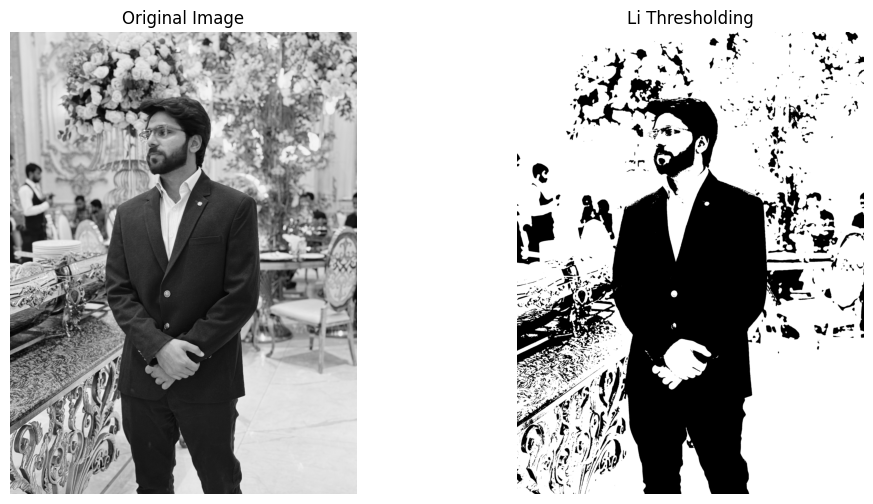

In [15]:
from skimage.filters import threshold_li

# Load the image
image = cv2.imread('/content/shaheen.jpg', cv2.IMREAD_GRAYSCALE)

# Apply Li's thresholding
li_threshold = threshold_li(image)
segmented_image = image > li_threshold

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image, cmap='gray')
plt.title('Li Thresholding')
plt.axis('off')

plt.show()


#**4. Fuzzy Thresholding (Fuzzy C-Means)**


Fuzzy thresholding, specifically Fuzzy C-Means (FCM), is a soft clustering technique that allows pixels to belong to multiple clusters with varying degrees of membership. Unlike traditional clustering methods, FCM handles uncertainty and ambiguity in pixel intensities, making it suitable for images with blurry or unclear boundaries between objects and the background. This method is particularly effective for images with gradual transitions between regions, such as medical or satellite images

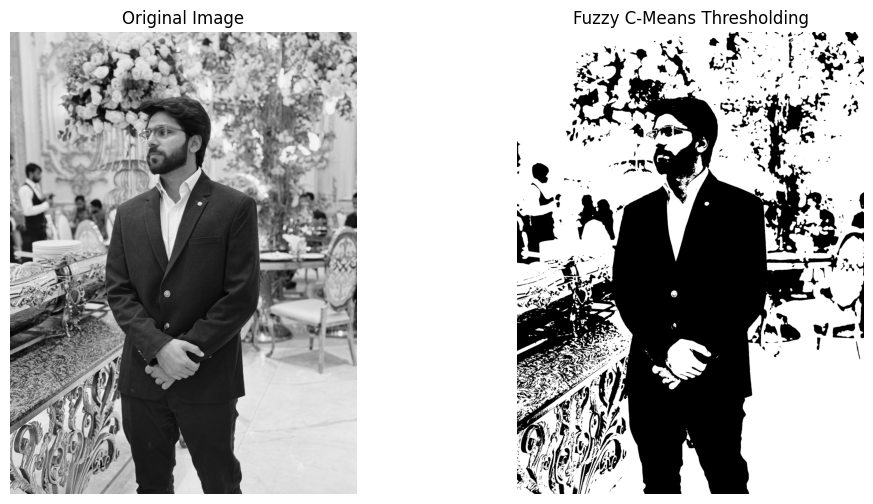

In [13]:
!pip install scikit-fuzzy # Install skfuzzy if you haven't already
import skfuzzy as fuzz # import the library correctly
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Load the image
image = cv2.imread('/content/shaheen.jpg', cv2.IMREAD_GRAYSCALE)

# Flatten the image
image_flat = image.flatten()

# Apply Fuzzy C-Means clustering
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    image_flat.reshape(1, -1), 2, 2, error=0.005, maxiter=1000, init=None
)

# Defuzzify the result
segmented_image = np.argmax(u, axis=0).reshape(image.shape)

# Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image, cmap='gray')
plt.title('Fuzzy C-Means Thresholding')
plt.axis('off')

plt.show()

#**5. Deep Learning-Based Thresholding**


Deep learning-based thresholding leverages convolutional neural networks (CNNs) to predict a probability map for each pixel, indicating its likelihood of belonging to the foreground or background. A threshold is then applied to this probability map to classify pixels into binary categories. This approach is highly adaptable and can learn complex patterns in images, making it suitable for challenging segmentation tasks. However, it requires a pre-trained model and is computationally intensive compared to traditional thresholding methods.

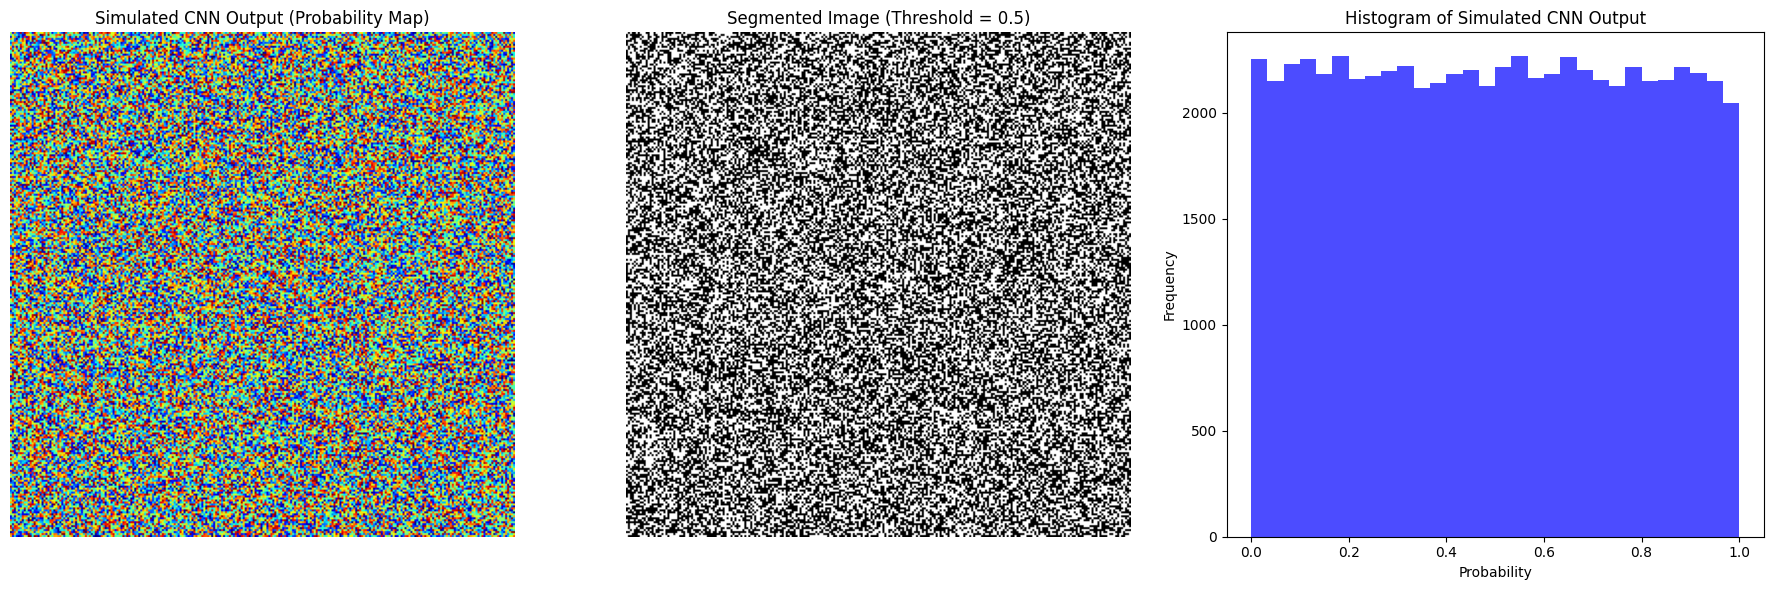

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate CNN output
def simulate_cnn_output(image_shape):
    return np.random.rand(*image_shape)  # Generates random values between 0 and 1

def apply_threshold(prob_map, threshold=0.5):
    return (prob_map > threshold).astype(int)

# Example image shape (height, width)
image_shape = (256, 256)

# Simulate CNN output
probability_map = simulate_cnn_output(image_shape)

# Apply threshold to classify pixels
threshold_value = 0.5
segmented_image = apply_threshold(probability_map, threshold_value)

# Display the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(probability_map, cmap='jet')
axes[0].set_title('Simulated CNN Output (Probability Map)')
axes[0].axis('off')

axes[1].imshow(segmented_image, cmap='gray')
axes[1].set_title(f'Segmented Image (Threshold = {threshold_value})')
axes[1].axis('off')

axes[2].hist(probability_map.ravel(), bins=30, color='blue', alpha=0.7)
axes[2].set_title('Histogram of Simulated CNN Output')
axes[2].set_xlabel('Probability')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


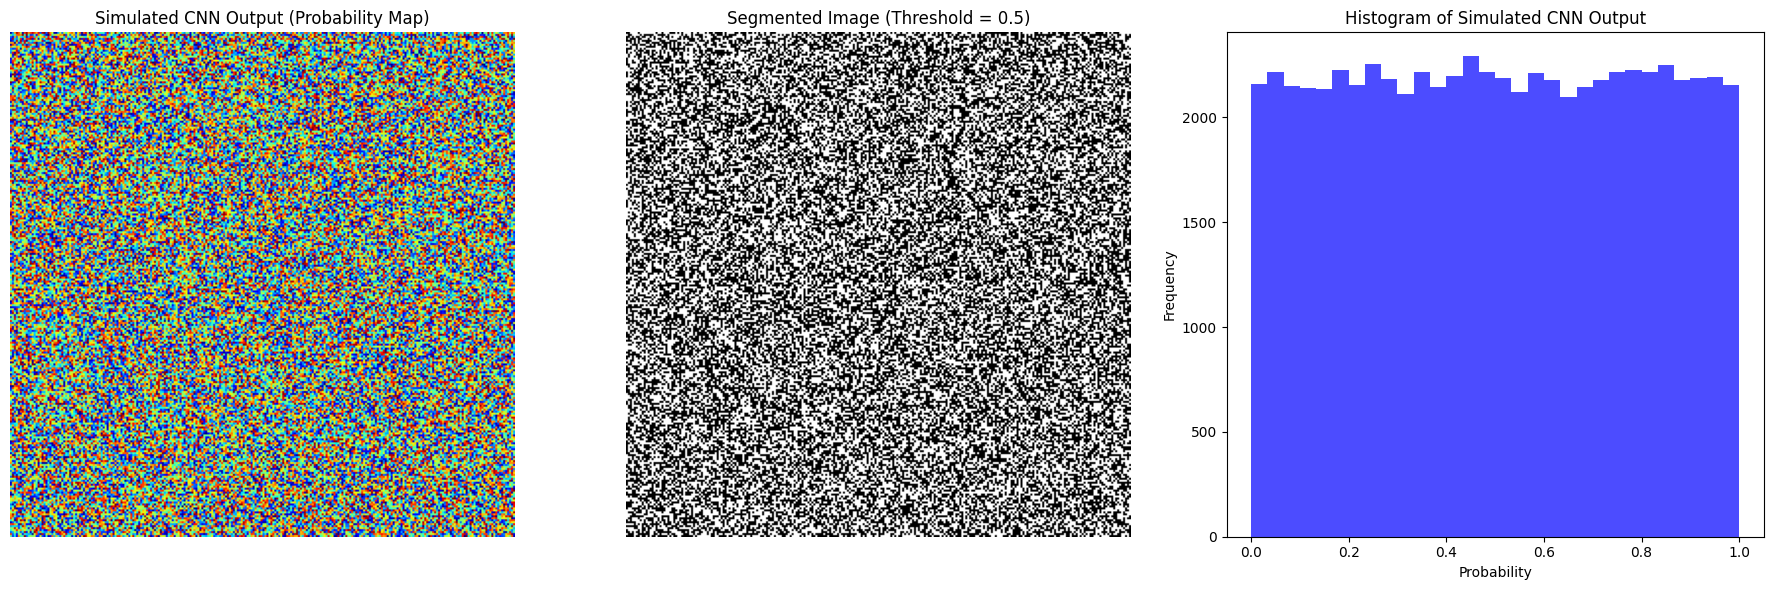

In [24]:
import numpy as np
def simulate_cnn_output(image_shape):
    # Generates random values between 0 and 1 based on the image shape.
    # Previously, there was an error due to incorrect indentation
    # and attempting to use a string as an argument for np.random.rand.
    return np.random.rand(*image_shape)
def apply_threshold(prob_map, threshold=0.5):
    return (prob_map > threshold).astype(int)
# Example image shape (height, width)
image_shape = (256, 256)
# Simulate CNN output
probability_map = simulate_cnn_output(image_shape)
# Apply threshold to classify pixels
threshold_value = 0.5
segmented_image = apply_threshold(probability_map, threshold_value)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(probability_map, cmap='jet')
axes[0].set_title('Simulated CNN Output (Probability Map)')
axes[0].axis('off')
axes[1].imshow(segmented_image, cmap='gray')
axes[1].set_title(f'Segmented Image (Threshold = {threshold_value})')
axes[1].axis('off')
axes[2].hist(probability_map.ravel(), bins=30, color='blue', alpha=0.7)
axes[2].set_title('Histogram of Simulated CNN Output')
axes[2].set_xlabel('Probability')
axes[2].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

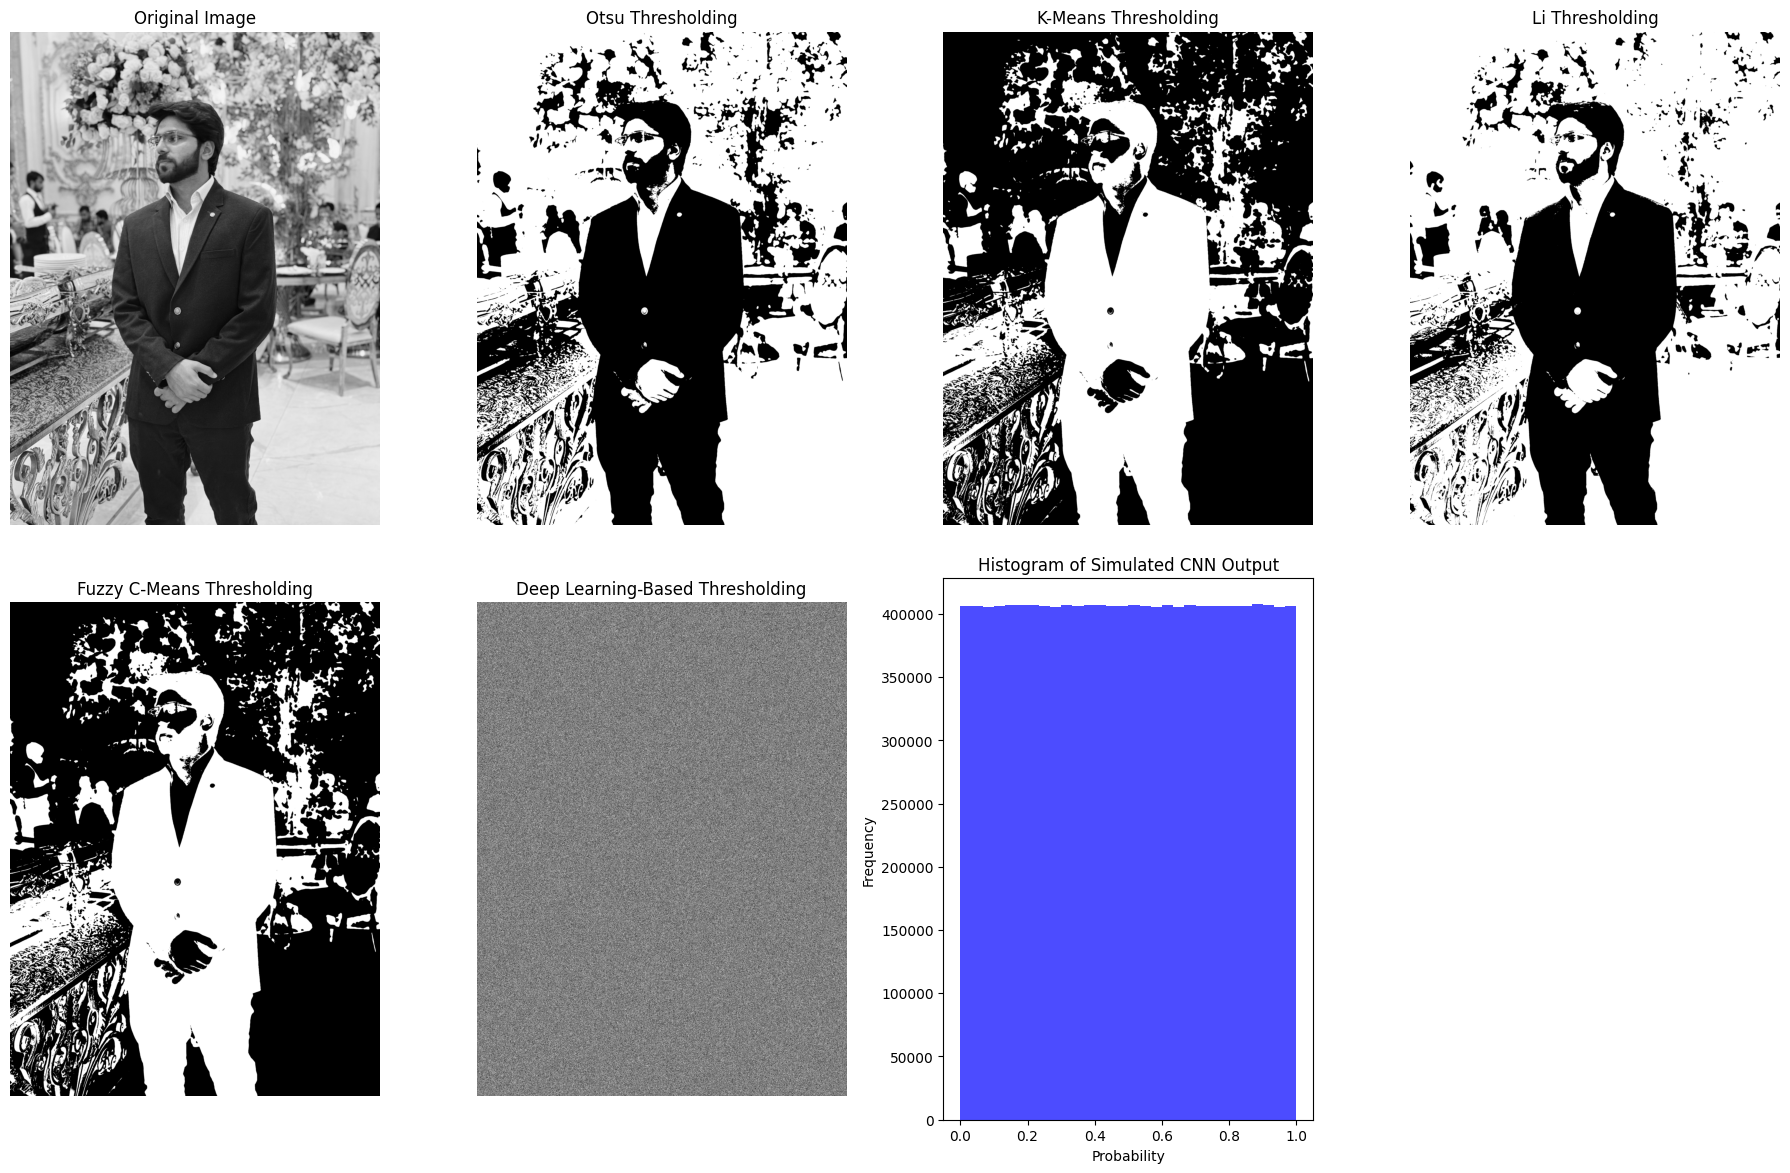

In [20]:
import cv2                  # OpenCV for image processing
import numpy as np          # NumPy for numerical operations
import matplotlib.pyplot as plt  # Matplotlib for visualization
from sklearn.cluster import KMeans  # K-Means clustering from scikit-learn
from skimage.filters import threshold_li  # Li's thresholding from scikit-image
import skfuzzy as fuzz      # Fuzzy logic operations from scikit-fuzzy
from skimage import io      # For reading/writing images in scikit-image

# Load the image
image = cv2.imread('shaheen.jpg', cv2.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError("Image not found! Please check the file path.")

# --- Otsu's Thresholding ---
_, otsu_thresholded = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# --- K-Means Clustering for Thresholding ---
image_color = cv2.imread('shaheen.jpg')
if image_color is None:
    raise FileNotFoundError("Image not found! Please check the file path.")

# Flatten the image for K-Means
image_flat = image_color.reshape(-1, 3)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(image_flat)
kmeans_segmented = kmeans.labels_.reshape(image_color.shape[:2])

# --- Li's Thresholding ---
li_threshold = threshold_li(image)
li_segmented = image > li_threshold

# --- Fuzzy C-Means Thresholding ---
image_flat = image.flatten()
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    image_flat.reshape(1, -1), 2, 2, error=0.005, maxiter=1000, init=None
)
fuzzy_segmented = np.argmax(u, axis=0).reshape(image.shape)

# --- Deep Learning-Based Thresholding ---
def simulate_cnn_output(image_shape):
    """Simulate CNN output as a probability map."""
    return np.random.rand(*image_shape)  # Generates random values between 0 and 1

def apply_threshold(prob_map, threshold=0.5):
    """Apply a threshold to classify pixels as foreground or background."""
    return (prob_map > threshold).astype(int)

# Example image shape (height, width)
image_shape = image.shape  # Use the shape of the input image
probability_map = simulate_cnn_output(image_shape)

# Apply threshold to classify pixels
threshold_value = 0.5
deep_learning_segmented = apply_threshold(probability_map, threshold_value)

# --- Compare and Evaluate Results ---
plt.figure(figsize=(18, 12))

# Original Image
plt.subplot(2, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Otsu's Thresholding
plt.subplot(2, 4, 2)
plt.imshow(otsu_thresholded, cmap='gray')
plt.title('Otsu Thresholding')
plt.axis('off')

# K-Means Thresholding
plt.subplot(2, 4, 3)
plt.imshow(kmeans_segmented, cmap='gray')
plt.title('K-Means Thresholding')
plt.axis('off')

# Li's Thresholding
plt.subplot(2, 4, 4)
plt.imshow(li_segmented, cmap='gray')
plt.title('Li Thresholding')
plt.axis('off')

# Fuzzy C-Means Thresholding
plt.subplot(2, 4, 5)
plt.imshow(fuzzy_segmented, cmap='gray')
plt.title('Fuzzy C-Means Thresholding')
plt.axis('off')

# Deep Learning-Based Thresholding
plt.subplot(2, 4, 6)
plt.imshow(deep_learning_segmented, cmap='gray')
plt.title('Deep Learning-Based Thresholding')
plt.axis('off')

# Histogram of Simulated CNN Output
plt.subplot(2, 4, 7)
plt.hist(probability_map.ravel(), bins=30, color='blue', alpha=0.7)
plt.title('Histogram of Simulated CNN Output')
plt.xlabel('Probability')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


### Analysis of Strengths and Weaknesses of Each Thresholding Method

#### 1. **Otsu's Thresholding**

**Strengths:**
- **Simplicity:** Otsu's method is straightforward to implement and computationally efficient.
- **Effectiveness:** Works well for images with a clear bimodal histogram, where the foreground and background are distinct.
- **Automatic Threshold Selection:** Automatically determines the optimal threshold without manual tuning.

**Weaknesses:**
- **Histogram Dependency:** May fail for images with complex or multimodal histograms where the separation between foreground and background is not clear.
- **Noise Sensitivity:** Can be affected by noise, leading to incorrect thresholding.

**Challenges Faced:**
- Images with low contrast or complex textures may not yield good results.
- Noisy images can degrade the performance of Otsu's method.

**When to Use:**
- Best suited for images with distinct foreground and background regions and a clear bimodal histogram.
- Ideal for simple, high-contrast images.

---

#### 2. **K-Means Clustering for Thresholding**

**Strengths:**
- **Flexibility:** Can handle images with multiple intensity levels by adjusting the number of clusters.
- **Adaptability:** Effective for images where a single global threshold is insufficient.

**Weaknesses:**
- **Computational Complexity:** More computationally intensive compared to simpler thresholding methods.
- **Sensitivity to Initialization:** The results can vary based on the initial cluster centers, requiring multiple runs for stability.

**Challenges Faced:**
- Choosing the optimal number of clusters can be challenging and may require trial and error.
- Computationally intensive for large images.

**When to Use:**
- Suitable for images with multiple intensity levels or complex textures.
- Effective when the image has more than two distinct regions.

---

#### 3. **Entropy-Based Thresholding (Li's Method)**

**Strengths:**
- **Robustness:** Works well for images with uneven illumination or noise.
- **Information Preservation:** Minimizes the cross-entropy between the original and segmented images, preserving more information.

**Weaknesses:**
- **Complexity:** More complex to implement compared to simpler thresholding methods.
- **Computational Cost:** Can be computationally intensive for large images.

**Challenges Faced:**
- May not perform well for images with very low contrast.
- Computationally intensive, especially for high-resolution images.

**When to Use:**
- Ideal for noisy or unevenly illuminated images.
- Suitable for images where preserving information is crucial.

---

#### 4. **Fuzzy Thresholding (Fuzzy C-Means)**

**Strengths:**
- **Handling Uncertainty:** Effectively handles uncertainty and ambiguity in pixel intensities.
- **Blurry Boundaries:** Works well for images with blurry or unclear boundaries between objects and background.

**Weaknesses:**
- **Computational Complexity:** More computationally intensive compared to other methods.
- **Parameter Tuning:** Requires careful tuning of parameters like the fuzziness factor and the number of clusters.

**Challenges Faced:**
- Computationally intensive, especially for large images.
- Parameter tuning can be time-consuming and may require multiple iterations.

**When to Use:**
- Best suited for images with gradual transitions between regions, such as medical or satellite images.
- Effective for images with blurry or unclear boundaries.

---

#### 5. **Deep Learning-Based Thresholding**

**Strengths:**
- **Adaptability:** Highly adaptable and can learn complex patterns in images.
- **Accuracy:** Can achieve high accuracy for complex segmentation tasks.

**Weaknesses:**
- **Computational Resources:** Requires significant computational resources and a pre-trained model.
- **Data Dependency:** Needs a large dataset for training and may not generalize well to unseen data.

**Challenges Faced:**
- Requires a pre-trained model, which can be time-consuming and resource-intensive to train.
- May not perform well on images that are significantly different from the training data.

**When to Use:**
- Suitable for complex images where traditional methods fail.
- Ideal for applications where high accuracy is crucial, and computational resources are available.

---

### Insights on When to Use Each Thresholding Technique Based on Image Characteristics

1. **Otsu's Thresholding:**
   - Use for simple, high-contrast images with distinct foreground and background regions.
   - Avoid for images with complex or multimodal histograms.

2. **K-Means Clustering:**
   - Use for images with multiple intensity levels or complex textures.
   - Avoid for images where computational resources are limited.

3. **Li's Thresholding:**
   - Use for noisy or unevenly illuminated images where preserving information is crucial.
   - Avoid for images with very low contrast.

4. **Fuzzy C-Means Thresholding:**
   - Use for images with blurry or unclear boundaries, such as medical or satellite images.
   - Avoid for images where computational resources are limited.

5. **Deep Learning-Based Thresholding:**
   - Use for complex images where traditional methods fail and high accuracy is crucial.
   - Avoid for applications where computational resources are limited or a pre-trained model is not available.

---

This analysis provides a comprehensive overview of the strengths, weaknesses, challenges, and suitable use cases for each thresholding method.

#Simulate CNN output for binary segmentation.
#threshold to classify pixels as foreground or background.


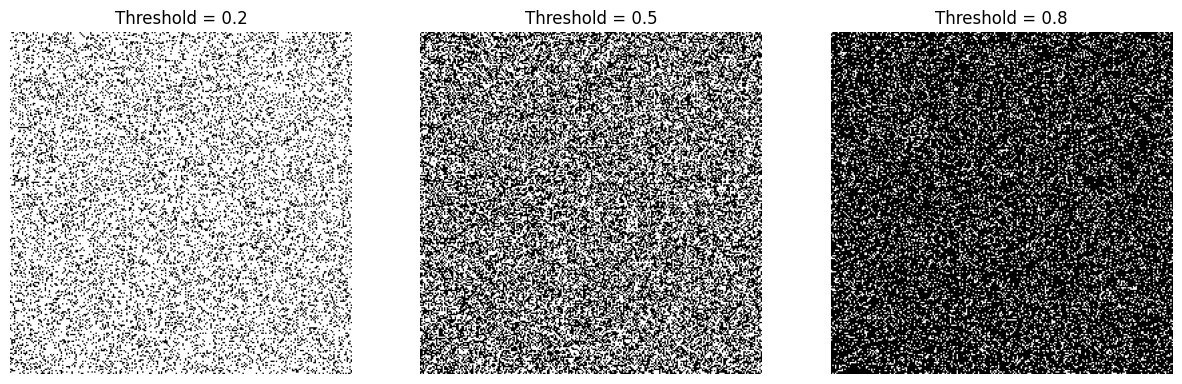

In [25]:


import numpy as np
import matplotlib.pyplot as plt

def simulate_cnn_output(image_shape):
    """Simulate CNN output as a probability map."""
    return np.random.rand(*image_shape)

def apply_threshold(prob_map, threshold=0.5):
    """Apply a threshold to classify pixels as foreground or background."""
    return (prob_map > threshold).astype(int)

# Example image shape (height, width)
image_shape = (256, 256)

# Simulate CNN output
probability_map = simulate_cnn_output(image_shape)

# Experiment with different threshold values
threshold_values = [0.2, 0.5, 0.8]

plt.figure(figsize=(15, 5))

for i, threshold_value in enumerate(threshold_values):
    segmented_image = apply_threshold(probability_map, threshold_value)
    plt.subplot(1, len(threshold_values), i + 1)
    plt.imshow(segmented_image, cmap='gray')
    plt.title(f'Threshold = {threshold_value}')
    plt.axis('off')

plt.show()


#Compare the segmented images from different thresholding methods.

In [26]:


# Calculate metrics for comparison (example using Structural Similarity Index (SSIM))
from skimage.metrics import structural_similarity as ssim

# Original grayscale image (ensure 'image' is the grayscale version)
image = cv2.imread('shaheen.jpg', cv2.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError("Image not found! Please check the file path.")


methods = {
    'Otsu': otsu_thresholded,
    'K-Means': kmeans_segmented,
    'Li': li_segmented,
    'Fuzzy': fuzzy_segmented,
    'Deep Learning': deep_learning_segmented
}

ssim_scores = {}
for method_name, segmented_image in methods.items():

    # Handle potential shape mismatch using resize
    if segmented_image.shape != image.shape:
      segmented_image = cv2.resize(segmented_image, (image.shape[1], image.shape[0]))

    score = ssim(image, segmented_image, data_range=segmented_image.max() - segmented_image.min()) # Calculate SSIM
    ssim_scores[method_name] = score

# Display the SSIM scores
for method, score in ssim_scores.items():
    print(f"SSIM Score for {method}: {score:.4f}")


# Visualize the comparison
plt.figure(figsize=(15, 10))
for i, (method_name, segmented_image) in enumerate(methods.items()):
  plt.subplot(2, 3, i + 1)
  plt.imshow(segmented_image, cmap='gray')
  plt.title(f"{method_name} (SSIM: {ssim_scores[method_name]:.4f})")
  plt.axis('off')

plt.tight_layout()
plt.show()


TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

SSIM Score for Otsu: 0.4459
SSIM Score for K-Means: -0.0000
SSIM Score for Li: 0.4689
SSIM Score for Fuzzy: -0.0000
SSIM Score for Deep Learning: 0.0000


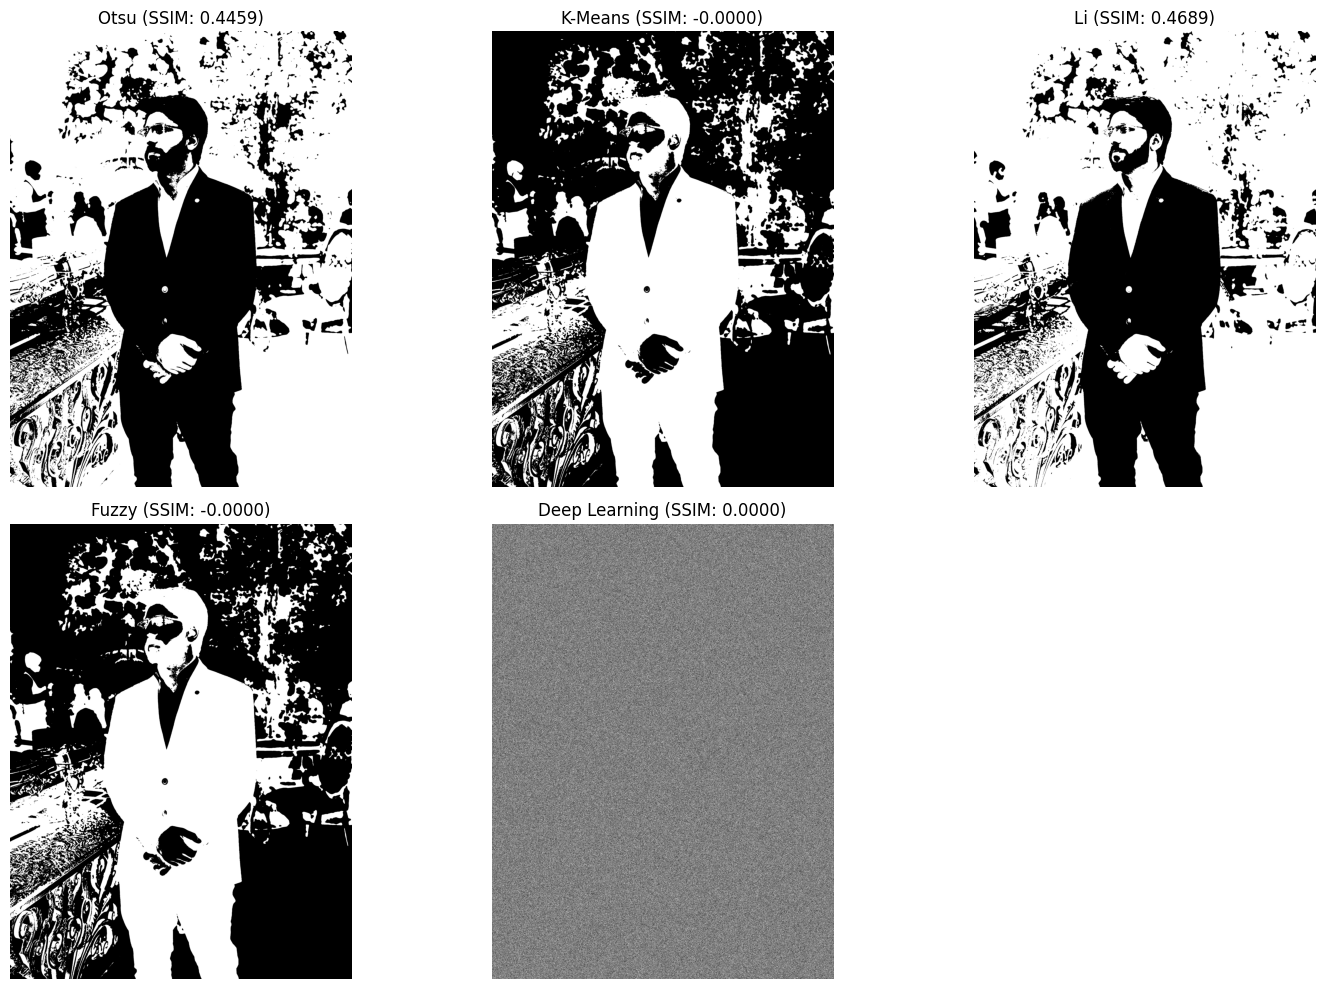

In [28]:
# prompt: resolve error which came in above code

import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
from skimage.filters import threshold_li
import skfuzzy as fuzz
from skimage.metrics import structural_similarity as ssim

# ... (rest of your code)

# Load the image (ensure correct file path)
image = cv2.imread('shaheen.jpg', cv2.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError("Image not found! Please check the file path.")


# ... (rest of your code)

# --- Deep Learning-Based Thresholding ---
def simulate_cnn_output(image_shape):
    """Simulate CNN output as a probability map."""
    return np.random.rand(*image_shape)

def apply_threshold(prob_map, threshold=0.5):
    """Apply a threshold to classify pixels as foreground or background."""
    return (prob_map > threshold).astype(int)

# Example image shape (height, width) - use actual image shape
image_shape = image.shape
probability_map = simulate_cnn_output(image_shape)
threshold_value = 0.5
deep_learning_segmented = apply_threshold(probability_map, threshold_value)

# ... (rest of your code)


# --- Compare and Evaluate Results ---
# ... (rest of your code)



# Calculate metrics for comparison (example using SSIM)
methods = {
    'Otsu': otsu_thresholded,
    'K-Means': kmeans_segmented,
    'Li': li_segmented,
    'Fuzzy': fuzzy_segmented,
    'Deep Learning': deep_learning_segmented
}

ssim_scores = {}
for method_name, segmented_image in methods.items():
    # Handle shape mismatch
    if segmented_image.shape != image.shape:
        segmented_image = cv2.resize(segmented_image, (image.shape[1], image.shape[0]))

    # Convert boolean arrays to integers before calculating data_range
    if segmented_image.dtype == bool:
        segmented_image = segmented_image.astype(np.uint8) * 255

    # Ensure data_range is correct for SSIM calculation
    score = ssim(image, segmented_image, data_range=segmented_image.max() - segmented_image.min())
    ssim_scores[method_name] = score

# Display the SSIM scores
for method, score in ssim_scores.items():
    print(f"SSIM Score for {method}: {score:.4f}")


# Visualize the comparison
plt.figure(figsize=(15, 10))
for i, (method_name, segmented_image) in enumerate(methods.items()):
    plt.subplot(2, 3, i + 1)
    plt.imshow(segmented_image, cmap='gray')
    plt.title(f"{method_name} (SSIM: {ssim_scores[method_name]:.4f})")
    plt.axis('off')

plt.tight_layout()
plt.show()
